# Exploring the CRCNS AA1 and AA2 datasets with deepSTRF

This notebook walks through the deepSTRF dataset API on two closely related
auditory neurophysiology datasets:

- **[CRCNS AA1](https://crcns.org/data-sets/aa/aa-1/about)** (Theunissen et al.,
  2009) — single-unit spike trains from the Field-L and MLd regions of
  anesthetized zebra finches, responding to conspecific songs and flat ripples.
- **[CRCNS AA2](https://crcns.org/data-sets/aa/aa-2/about)** (Gill et al., 2006 /
  Amin et al., 2010) — same species, larger cohort (~500 neurons across Field-L,
  MLd, OV, CM), three stim classes (conspecific, flat ripples, song ripples).

By the end, you will have seen:

1. How to **instantiate** a deepSTRF dataset.
2. How the data are **stored internally** (list-of-lists, NaN-sentinel
   missingness) — see
   [`data_paradigm.md`](../docs/_source/md/data_paradigm.md) for the full
   design rationale.
3. How to **visualize** a stimulus spectrogram and its recorded PSTH.
4. How to use the **neuron selection API** (`select_neuron`,
   `select_pop_by_nrn_attr`, …).
5. How to iterate the dataset with a **PyTorch `DataLoader`** via the
   batch-collate function.

**Prerequisite:** the raw AA1 / AA2 data are downloaded from crcns.org and
placed somewhere on disk. Update the path variables in the next cell.


## Setup


In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

from deepSTRF.datasets.audio.CRCNS_AA1_Dataset import CRCNS_AA1_Dataset
from deepSTRF.datasets.audio.CRCNS_AA2_Dataset import CRCNS_AA2_Dataset
from deepSTRF.utils.data import aa4_collate   # TODO: rename to neural_collate

# Update to your local paths. These default to the in-repo dev copies.
AA1_PATH = "../deepSTRF/datasets/audio/CRCNS_AA1/data/"
AA2_PATH = "../deepSTRF/datasets/audio/CRCNS_AA2/data/"

# Bin width in ms. Typical choices: 1, 5, 10.
DT_MS = 5


## 1. Instantiating AA1

The constructor takes a `path` to the data folder, plus dataset-specific
selection arguments (recording area, stimulus type, animal, bin width, …).
All stimuli and responses are preprocessed in the constructor so the object
is ready for iteration immediately.


In [2]:
aa1 = CRCNS_AA1_Dataset(
    path=AA1_PATH,
    areas=("Field_L", "MLd"),
    stimuli=("conspecific", "flatrip"),
    dt_ms=DT_MS,
)
aa1


CRCNS_AA1_Dataset(N_neurons=100, selected=0, N_stims=30, dt_ms=5)

## 2. How data are stored

deepSTRF datasets are **triply ragged** — stimulus duration varies, repeat count
varies per (stim, neuron), and coverage is sparse (not every neuron heard every
stim). They are stored as Python lists of tensors rather than stacked tensors,
with NaN as the single channel for encoding missingness.

Core attributes populated by every `NeuralDataset` subclass:

| attribute             | shape / structure                                                              |
|-----------------------|--------------------------------------------------------------------------------|
| `self.stims`          | length-S list; each element is a `(1, F, T_s)` mel-spectrogram (T varies)      |
| `self.responses`      | length-S list of length-N lists; `responses[s][n]` is `(R_{s,n}, T_s)` or `(1, 1)` NaN |
| `self.stim_meta`      | length-S list of per-stim tuples `(stim_name, stim_type)`                      |
| `self.neuron_metadata`| length-N list of per-neuron tuples `(cell_id, animal_id, area)`                |
| `self.nrn_masks`      | `(S, N)` bool tensor derived from the NaN sentinels                            |

Let's confirm all the shapes are consistent with the paradigm.


In [3]:
print(f"S (stimuli)           = {aa1.get_S()}")
print(f"N (neurons)           = {aa1.get_N()}")
print(f"dt                    = {aa1.dt} ms")
print()
print(f"stims[0].shape        = {tuple(aa1.stims[0].shape)}  (1, F, T_0)")
print(f"stim T range          = [{min(s.shape[-1] for s in aa1.stims)}, "
      f"{max(s.shape[-1] for s in aa1.stims)}]  bins")
print()
print(f"responses[0][0] shape = {tuple(aa1.responses[0][0].shape)}")
print(f"stim_meta[0]          = {aa1.stim_meta[0]}")
print(f"neuron_metadata[0]    = {aa1.neuron_metadata[0]}")
print()
print(f"nrn_masks.shape       = {tuple(aa1.nrn_masks.shape)}, dtype = {aa1.nrn_masks.dtype}")
print(f"nrn_masks valid       = {int(aa1.nrn_masks.sum())} / {aa1.nrn_masks.numel()} "
      f"({100 * aa1.nrn_masks.float().mean().item():.1f}%)")


S (stimuli)           = 30
N (neurons)           = 100
dt                    = 5 ms

stims[0].shape        = (1, 32, 389)  (1, F, T_0)
stim T range          = [330, 501]  bins

responses[0][0] shape = (10, 389)
stim_meta[0]          = ('058767E725C83836F405A97FD7D1E751.wav', 'conspecific')
neuron_metadata[0]    = ('gg0304_10_B', 'gg0304', 'Field_L')

nrn_masks.shape       = (30, 100), dtype = torch.bool
nrn_masks valid       = 2960 / 3000 (98.7%)


## 3. Visualizing a stimulus

Stimuli are mel-spectrograms of shape `(1, F, T)`, stored as float tensors.
Let's plot one.


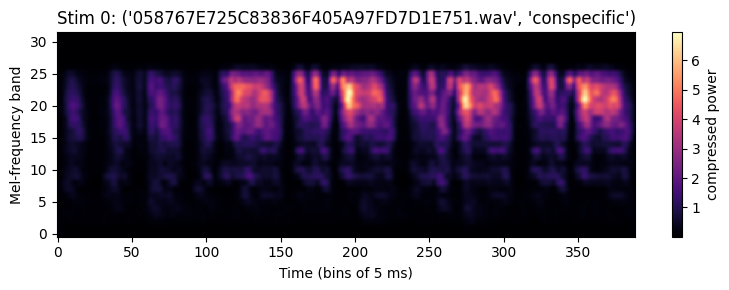

In [4]:
stim_idx = 0
stim = aa1.stims[stim_idx].squeeze(0)   # (F, T)
fig, ax = plt.subplots(figsize=(8, 3))
im = ax.imshow(stim.numpy(), aspect="auto", origin="lower", cmap="magma")
ax.set_xlabel(f"Time (bins of {aa1.dt} ms)")
ax.set_ylabel("Mel-frequency band")
ax.set_title(f"Stim {stim_idx}: {aa1.stim_meta[stim_idx]}")
fig.colorbar(im, ax=ax, label="compressed power")
plt.tight_layout()
plt.show()


## 4. Visualizing a response

Responses are spike-count tensors per (stim, neuron) pair, shaped `(R, T)` —
one row per repeat. The trial-averaged PSTH is `response.mean(dim=0)`.

Note: missing (stim, neuron) pairs are `(1, 1)` NaN tensors, so we pick a
(stim, neuron) pair that the `nrn_masks` confirms as real data.


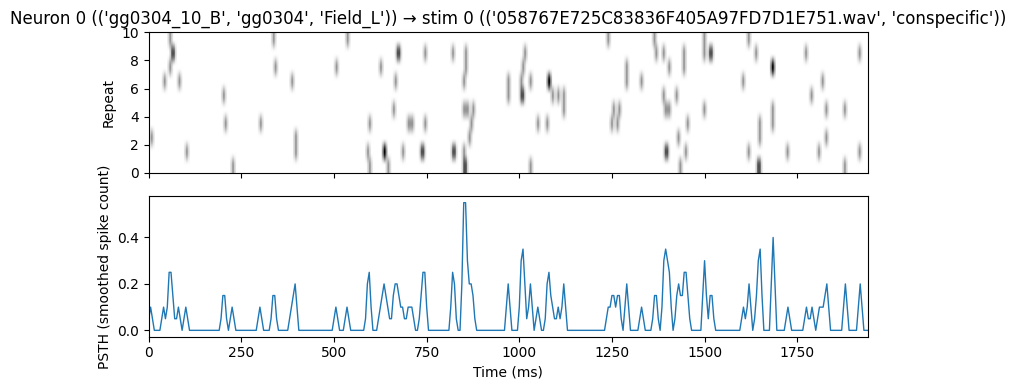

In [5]:
# find a (s, n) pair that has real data
valid_pairs = aa1.nrn_masks.nonzero()
stim_idx, neuron_idx = valid_pairs[0].tolist()

spikes = aa1.responses[stim_idx][neuron_idx]                   # (R, T)
psth = spikes.mean(dim=0)                                       # (T,)
time_ms = torch.arange(spikes.shape[-1]) * aa1.dt

fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(8, 4), sharex=True)
ax0.imshow(spikes.numpy(), aspect="auto", cmap="Greys",
           extent=[0, float(time_ms[-1]), 0, spikes.shape[0]])
ax0.set_ylabel("Repeat")
ax0.set_title(f"Neuron {neuron_idx} ({aa1.neuron_metadata[neuron_idx]}) "
              f"→ stim {stim_idx} ({aa1.stim_meta[stim_idx]})")
ax1.plot(time_ms, psth.numpy(), lw=1)
ax1.set_xlabel("Time (ms)")
ax1.set_ylabel("PSTH (smoothed spike count)")
plt.tight_layout()
plt.show()


## 5. Coverage: the `nrn_masks` tensor

`self.nrn_masks` is an `(S, N)` bool tensor — `True` iff neuron *n* has real
data for stimulus *s*. It is derived at the end of `__init__` by scanning
`self.responses` for the NaN sentinel. A heatmap makes the sparse coverage
pattern obvious.


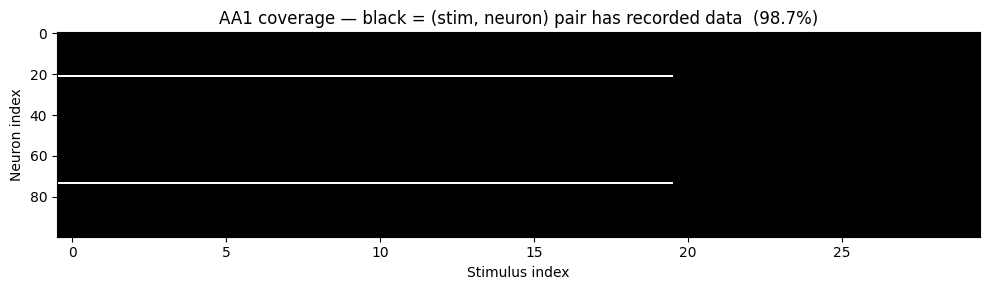

In [6]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.imshow(aa1.nrn_masks.T.numpy(), aspect="auto", cmap="Greys", interpolation="nearest")
ax.set_xlabel("Stimulus index")
ax.set_ylabel("Neuron index")
ax.set_title(f"AA1 coverage — black = (stim, neuron) pair has recorded data  "
             f"({100 * aa1.nrn_masks.float().mean().item():.1f}%)")
plt.tight_layout()
plt.show()


## 6. Selecting a sub-population

`__getitem__` and `__len__` operate on the subset of neurons currently
selected by `self.I`. Three helpers populate it:

- `select_neuron(i)` — single neuron by integer index.
- `select_population([i, j, …])` — an explicit list of indices.
- `select_pop_by_nrn_attr(attr, value)` — all neurons whose
  `neuron_metadata[attr] == value` (dict-style access; tuples work if you
  rely on position-based selection instead).

Selection is stateful — call as many times as you like; the dataset reflects
the most recent call on every subsequent `__getitem__`.


In [7]:
# select all MLd neurons (AA1 stores (cell_id, animal_id, area) tuples)
mld_idx = [n for n, meta in enumerate(aa1.neuron_metadata) if meta[2] == "MLd"]
aa1.select_population(mld_idx)

print(f"Selected {len(aa1.I)} MLd neurons out of {aa1.N_neurons} total.")
print(f"len(aa1) now returns: {len(aa1)}  (stims with >=1 valid selected neuron)")


Selected 50 MLd neurons out of 100 total.
len(aa1) now returns: 30  (stims with >=1 valid selected neuron)


## 7. Batching with a DataLoader

Because stim duration `T_s` and repeat count `R_{s,n}` both vary across items,
the default PyTorch collate can't stack items into a single tensor. Use
`deepSTRF.utils.data.aa4_collate` (soon to be renamed `neural_collate`), which
right-pads stims with zeros and responses with NaN.

One yielded batch is a 4-tuple: `(stims, responses, mask, stim_metas)`. See
`data_paradigm.md` §5 for exact shapes and §6 for the recommended loss
pattern.


In [8]:
loader = DataLoader(aa1, batch_size=4, shuffle=False, collate_fn=aa4_collate)
stims, responses, mask, stim_metas = next(iter(loader))

print(f"stims shape       : {tuple(stims.shape)}  (B, 1, F, T_max)")
print(f"responses shape   : {tuple(responses.shape)}  (B, N_selected, R_max, T_max)")
print(f"mask shape        : {tuple(mask.shape)}  (B, N_selected)")
print(f"stim_metas        : {stim_metas}")
print()
print("NaN positions in responses mark batch-level padding + missing (stim, neuron) pairs:")
print(f"  total NaN fraction = {responses.isnan().float().mean().item():.3f}")
print(f"  fully-NaN slabs (neuron didn't hear stim) per item: "
      f"{[int((responses[b].isnan().all(dim=(1, 2))).sum()) for b in range(responses.shape[0])]}")


stims shape       : (4, 1, 32, 460)  (B, 1, F, T_max)
responses shape   : (4, 50, 15, 460)  (B, N_selected, R_max, T_max)
mask shape        : (4, 50)  (B, N_selected)
stim_metas        : [('058767E725C83836F405A97FD7D1E751.wav', 'conspecific'), ('0A07B255BF830083B6726388CA8510BA.wav', 'conspecific'), ('1470489635DD93410408CE9F8FB2F7D9.wav', 'conspecific'), ('42FED9F3EF45A238202B050B06F91652.wav', 'conspecific')]

NaN positions in responses mark batch-level padding + missing (stim, neuron) pairs:
  total NaN fraction = 0.420
  fully-NaN slabs (neuron didn't hear stim) per item: [1, 1, 1, 1]


## 8. Switching to AA2

AA2 uses the exact same interface — just a different data directory and a
richer set of recording areas and stimulus classes. Skipping the smoothing
to speed up instantiation below.


In [9]:
aa2 = CRCNS_AA2_Dataset(
    path=AA2_PATH,
    areas=("Field_L", "mld", "OV", "CM"),
    stimuli=("conspecific", "songrip", "flatrip"),
    dt_ms=DT_MS,
    smooth=False,
)
print(aa2)
print(f"coverage: {int(aa2.nrn_masks.sum())} / {aa2.nrn_masks.numel()} "
      f"({100 * aa2.nrn_masks.float().mean().item():.1f}%)")

# same API, same 4-tuple from the collate:
aa2.select_population(list(range(min(aa2.N_neurons, 32))))   # take 32 neurons to keep the batch small
loader = DataLoader(aa2, batch_size=4, shuffle=False, collate_fn=aa4_collate)
stims, responses, mask, stim_metas = next(iter(loader))
print(f"AA2 batch stims shape     : {tuple(stims.shape)}")
print(f"AA2 batch responses shape : {tuple(responses.shape)}")


CRCNS_AA2_Dataset(N_neurons=428, selected=0, N_stims=104, dt_ms=5)
coverage: 16655 / 44512 (37.4%)
AA2 batch stims shape     : (4, 1, 32, 379)
AA2 batch responses shape : (4, 32, 10, 379)


## Recap

- Every deepSTRF dataset exposes the same core attributes — `stims`,
  `responses`, `stim_meta`, `neuron_metadata`, `nrn_masks` — regardless of
  the underlying modality or source.
- Missingness on the response side is encoded as NaN (see `data_paradigm.md`
  for why). The `nrn_masks` tensor is the canonical "does this (stim, neuron)
  pair have data" query.
- A single collate function handles the ragged batch-padding. Loss code
  recovers a fine-grained `valid_mask` from `~responses.isnan()`.
- Neuron sub-population selection is stateful via `self.I` — the same
  dataset object works as a single-neuron dataset or a population dataset
  depending on the most recent `select_*` call.

Next: see the `fit_audio_*.ipynb` notebooks for examples of actually fitting
a model on these datasets.
